In [39]:
import pandas as pd

/tmp/ipykernel_2504179/2514069633.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_compact["Task"] = pd.Categorical(df_compact["Task"], categories=task_order, ordered=True)
/tmp/ipykernel_2504179/2514069633.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_compact["Data_Type"] = pd.Categorical(df_compact["Data_Type"], categories=dtype_order, ordered=True)
/tmp/ipykernel_2504179/2514069633.py:37: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in

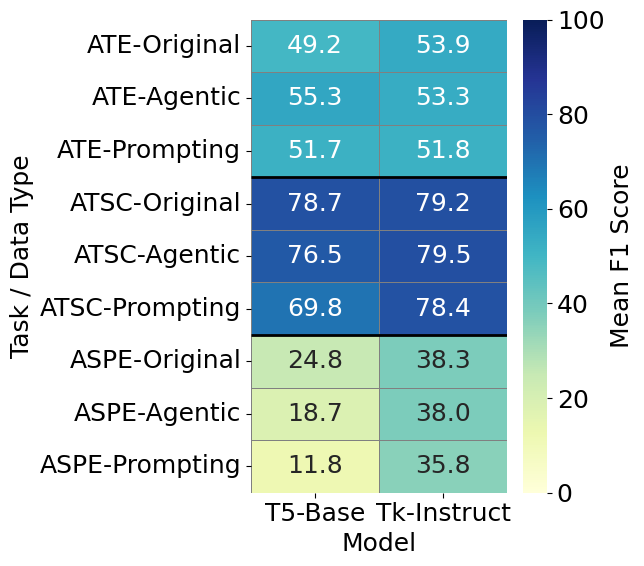

In [90]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

data = {
    "Task": ["ATE"]*6 + ["ATSC"]*6 + ["ASPE"]*6,
    "Model": ["T5-Base"]*3 + ["Tk-Instruct"]*3 + ["T5-Base"]*3 + ["Tk-Instruct"]*3 + ["T5-Base"]*3 + ["Tk-Instruct"]*3,
    "Data_Type": ["Original", "Agentic", "Prompting"]*6,
    "Laptop14": [41.06, 49.44, 40.59, 44.45, 44.10, 43.02,
                 71.31, 70.84, 67.22, 75.23, 74.29, 69.12,
                 11.43, 11.81, 3.30, 26.31, 26.84, 24.39],
    "Rest14": [64.68, 67.59, 68.95, 66.24, 65.86, 64.35,
               76.78, 74.02, 65.77, 76.78, 76.87, 77.41,
               36.58, 25.05, 20.34, 44.85, 46.72, 44.40],
    "Rest15": [41.81, 50.26, 45.42, 50.21, 47.87, 47.68,
               78.34, 75.00, 73.75, 79.15, 78.59, 78.96,
               25.24, 20.94, 10.01, 39.33, 36.42, 36.00],
    "Rest16": [49.45, 54.09, 51.76, 54.88, 55.18, 52.16,
               88.38, 86.17, 72.58, 85.69, 88.13, 88.13,
               26.06, 17.03, 13.54, 42.52, 41.83, 38.32]
}

df = pd.DataFrame(data)
df["Mean_F1"] = df[["Laptop14", "Rest14", "Rest15", "Rest16"]].mean(axis=1)
df_compact = df[["Task", "Model", "Data_Type", "Mean_F1"]]

# ---- Define desired order ----
task_order = ["ATE", "ATSC", "ASPE"]
dtype_order = ["Original", "Agentic", "Prompting"]

# Ensure categorical ordering
df_compact["Task"] = pd.Categorical(df_compact["Task"], categories=task_order, ordered=True)
df_compact["Data_Type"] = pd.Categorical(df_compact["Data_Type"], categories=dtype_order, ordered=True)

# ---- Pivot for heatmap ----
heatmap_data = df_compact.pivot_table(
    index=["Task", "Data_Type"], 
    columns="Model", 
    values="Mean_F1"
).reindex(
    pd.MultiIndex.from_product([task_order, dtype_order], names=["Task", "Data_Type"])
)



# ---- Plot ----
plt.figure(figsize=(6.5, 6))
ax = sns.heatmap(
    heatmap_data,
    annot=True, fmt=".1f",
    cmap="YlGnBu", vmin=0, vmax=100,
    linewidths=0.5, linecolor="gray",
    cbar_kws={"label": "Mean F1 Score"}
)


plt.xlabel("Model")
plt.ylabel("Task / Data Type")

# ---- Add black separator lines between tasks ----
rows_per_task = len(dtype_order)
separators = np.arange(rows_per_task, len(task_order)*rows_per_task, rows_per_task)
for sep in separators:
    ax.hlines(sep, *ax.get_xlim(), colors="black", linewidth=2)

plt.tight_layout()
plt.show()


In [40]:
ate = pd.read_csv("/home/s6moakba/Thesis/abc/ATE_all_results.csv")
atsc = pd.read_csv("/home/s6moakba/Thesis/abc/ATSC_all_results.csv")
aspe = pd.read_csv("/home/s6moakba/Thesis/abc/ASPE_all_results.csv")


ate["Task"] = "ate"
atsc["Task"] = "atsc"
aspe["Task"] = "aspe"

In [41]:
df = pd.concat([ate, atsc, aspe], ignore_index=True)

# Filter out 'x2' variations
df = df[~df["Variation"].str.contains("x2", na=False)]

# Map training strategies
def map_strategy(variation):
    if "Original" in variation:
        return "Original"
    elif "Gen" in variation:
        return "Gen"
    elif "Mixed" in variation:
        return "Mixed"
    else:
        return "Unknown"

df["Training Strategy"] = df["Variation"].apply(map_strategy)

# Compute mean F1 score across all subtasks
f1_cols = ["Laptop14_F1", "Rest14_F1", "Rest15_F1", "Rest16_F1"]
df["Mean_F1"] = df[f1_cols].mean(axis=1)

# Group and average
summary = df.groupby(["Model", "Data_Source", "Training Strategy"])["Mean_F1"].mean().reset_index()

# Optional: Sort by model and strategy
summary = summary.sort_values(by=["Model", "Training Strategy"])

# Display
print(summary)

         Model Data_Source Training Strategy    Mean_F1
0      T5-Base     Agentic               Gen  58.482500
3      T5-Base   Prompting               Gen  53.930833
1      T5-Base     Agentic             Mixed  85.454167
4      T5-Base   Prompting             Mixed  84.478333
2      T5-Base    Original          Original  84.552500
5  Tk-Instruct     Agentic               Gen  59.222500
8  Tk-Instruct   Prompting               Gen  52.605833
6  Tk-Instruct     Agentic             Mixed  85.993333
9  Tk-Instruct   Prompting             Mixed  84.843333
7  Tk-Instruct    Original          Original  86.182500


In [42]:
def compute_improvement(df):
    # Get the original rows (baseline for each model)
    original = df[df["Data_Source"] == "Original"].set_index("Model")

    # Function to compute difference from the original row of the same model
    def diff_from_original(row):
        model = row["Model"]
        baseline = original.loc[model]
        return pd.Series({
            "Laptop14_Diff": row["Laptop14_F1"] - baseline["Laptop14_F1"],
            "Rest14_Diff": row["Rest14_F1"] - baseline["Rest14_F1"],
            "Rest15_Diff": row["Rest15_F1"] - baseline["Rest15_F1"],
            "Rest16_Diff": row["Rest16_F1"] - baseline["Rest16_F1"],
        })

    # Apply the function row-wise
    diffs = df.apply(diff_from_original, axis=1)

    # Merge diffs back to original DataFrame
    df_with_diff = pd.concat([df, diffs], axis=1)
    return df_with_diff

In [43]:
ate = compute_improvement(ate)
atsc = compute_improvement(atsc)
aspe = compute_improvement(aspe)

/tmp/ipykernel_2504179/97577974.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered["Mean_Delta_F1"] = filtered[delta_cols].mean(axis=1)


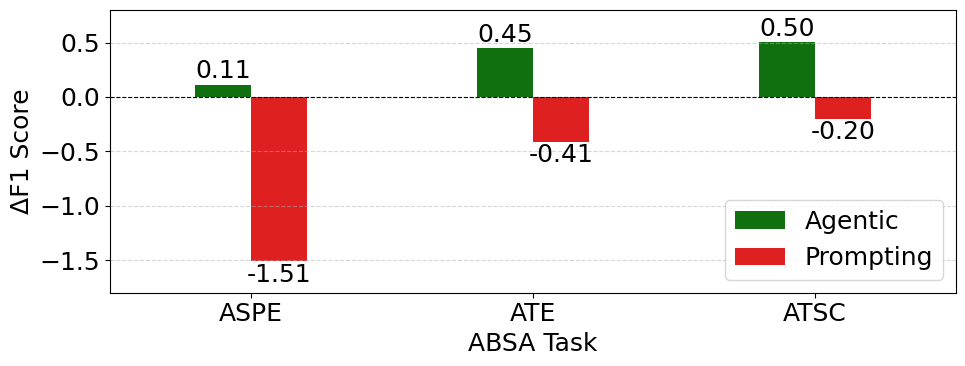

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator


# Assign task names if not already done
ate["Task"] = "ATE"
atsc["Task"] = "ATSC"
aspe["Task"] = "ASPE"

# Combine all task DataFrames
combined = pd.concat([ate, atsc, aspe], ignore_index=True)

# Keep only Mixed x1 rows for Agentic and Prompting
filtered = combined[
    (combined["Variation"] == "Mixed x1") &
    (combined["Data_Source"].isin(["Agentic", "Prompting"])) &
    (combined["Model"].isin(["T5-Base", "Tk-Instruct"]))
]

# Compute mean ΔF1 across all datasets
delta_cols = ["Laptop14_Diff", "Rest14_Diff", "Rest15_Diff", "Rest16_Diff"]
filtered["Mean_Delta_F1"] = filtered[delta_cols].mean(axis=1)

# Group by Task, Model, and Data Source
grouped = (
    filtered
    .groupby(["Task", "Data_Source"])["Mean_Delta_F1"]
    .mean()
    .reset_index()
)

# Create a label column for hue
grouped["Label"] = grouped["Data_Source"] 

plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
    "legend.title_fontsize": 18
})
# Plot
plt.figure(figsize=(10, 4))
ax = sns.barplot(
    data=grouped,
    x="Task",
    y="Mean_Delta_F1",
    hue="Label",
    palette=["green","red"],
    width = 0.4
)

# Add value labels on top
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=1)

ax.set_ylim([-1.8, 0.8])
# Style
ax.set_ylabel("ΔF1 Score")
ax.set_xlabel("ABSA Task")
ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax.yaxis.set_major_locator(MultipleLocator(0.5))  # Grid lines every 0.1
ax.grid(axis="y", linestyle="--", alpha=0.5)

ax.legend(loc="lower right")

plt.tight_layout()
plt.show()


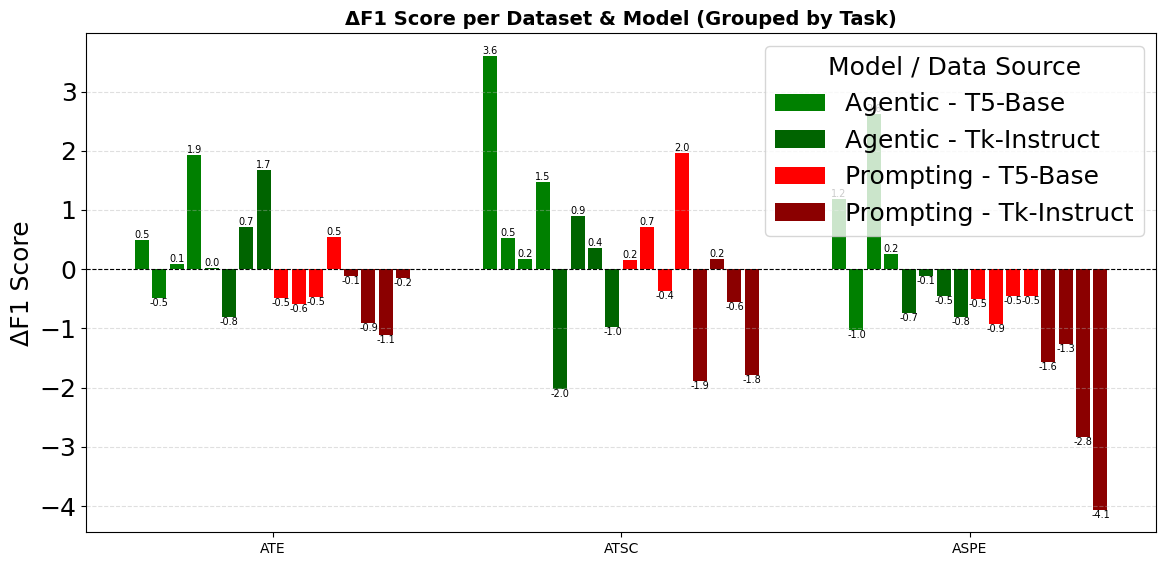

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Tag tasks
ate["Task"] = "ATE"
atsc["Task"] = "ATSC"
aspe["Task"] = "ASPE"

# Combine
df = pd.concat([ate, atsc, aspe], ignore_index=True)

# Filter to Mixed x1
df = df[
    (df["Variation"] == "Mixed x1") &
    (df["Data_Source"].isin(["Agentic", "Prompting"])) &
    (df["Model"].isin(["T5-Base", "Tk-Instruct"]))
]

# Melt delta F1 columns
df_melted = df.melt(
    id_vars=["Task", "Model", "Data_Source"],
    value_vars=["Laptop14_Diff", "Rest14_Diff", "Rest15_Diff", "Rest16_Diff"],
    var_name="Dataset",
    value_name="Delta_F1"
)

# Clean up
df_melted["Dataset"] = df_melted["Dataset"].str.replace("_Diff", "")
df_melted["Group"] = df_melted["Data_Source"] + " - " + df_melted["Model"]

# Set color map
color_map = {
    "Agentic - T5-Base": "green",
    "Agentic - Tk-Instruct": "darkgreen",
    "Prompting - T5-Base": "red",
    "Prompting - Tk-Instruct": "darkred"
}
df_melted["Color"] = df_melted["Group"].map(color_map)

# Ensure order: for each task, sort by Group then Dataset
group_order = ["Agentic - T5-Base", "Agentic - Tk-Instruct", "Prompting - T5-Base", "Prompting - Tk-Instruct"]
df_melted["Group"] = pd.Categorical(df_melted["Group"], categories=group_order, ordered=True)
df_melted = df_melted.sort_values(by=["Task", "Group", "Dataset"]).reset_index(drop=True)

# Assign new integer positions with spacing between tasks
task_positions = {"ATE": 0, "ATSC": 1, "ASPE": 2}
df_melted["Task_Pos"] = df_melted["Task"].map(task_positions)
df_melted["Bar_Pos"] = df_melted.groupby("Task").cumcount()
df_melted["X_Pos"] = df_melted["Task_Pos"] * 20 + df_melted["Bar_Pos"]

# Plot
plt.figure(figsize=(12, 6))
bars = plt.bar(
    x=df_melted["X_Pos"],
    height=df_melted["Delta_F1"],
    color=df_melted["Color"]
)

# Labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.1f}",
        ha="center",
        va="bottom" if height >= 0 else "top",
        fontsize=7
    )

# X-axis tick labels: one per task
tick_positions = [task_positions[task] * 20 + 7.5 for task in task_positions]
plt.xticks(tick_positions, labels=list(task_positions.keys()), fontsize=10)

# Styling
plt.axhline(0, color="black", linestyle="--", linewidth=0.8)
plt.ylabel("ΔF1 Score")
plt.title("ΔF1 Score per Dataset & Model (Grouped by Task)", fontsize=14, fontweight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.4)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="green", label="Agentic - T5-Base"),
    Patch(facecolor="darkgreen", label="Agentic - Tk-Instruct"),
    Patch(facecolor="red", label="Prompting - T5-Base"),
    Patch(facecolor="darkred", label="Prompting - Tk-Instruct"),
]
plt.legend(handles=legend_elements, title="Model / Data Source", loc="upper right")

plt.tight_layout()
plt.show()


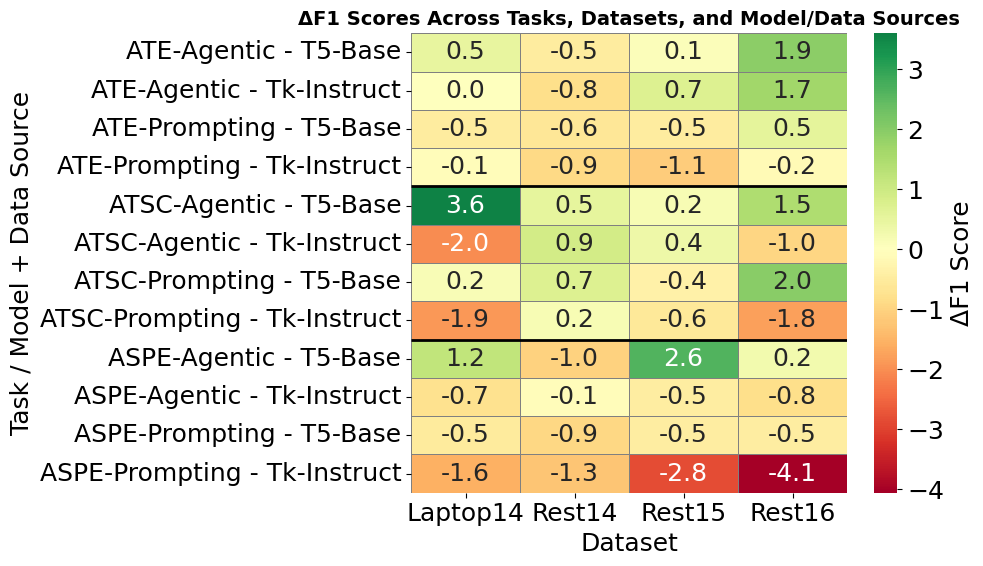

In [46]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Tag tasks
ate["Task"] = "ATE"
atsc["Task"] = "ATSC"
aspe["Task"] = "ASPE"

# Combine
df = pd.concat([ate, atsc, aspe], ignore_index=True)

# Filter relevant rows
df = df[
    (df["Variation"] == "Mixed x1") &
    (df["Data_Source"].isin(["Agentic", "Prompting"])) &
    (df["Model"].isin(["T5-Base", "Tk-Instruct"]))
]

# Create group label
df["Group"] = df["Data_Source"] + " - " + df["Model"]

# Melt diffs
df_melted = df.melt(
    id_vars=["Task", "Group"],
    value_vars=["Laptop14_Diff", "Rest14_Diff", "Rest15_Diff", "Rest16_Diff"],
    var_name="Dataset",
    value_name="Delta_F1"
)
df_melted["Dataset"] = df_melted["Dataset"].str.replace("_Diff", "")

# Create pivot table with multi-index
heatmap_data = df_melted.pivot_table(
    index=["Task", "Group"],
    columns="Dataset",
    values="Delta_F1"
).reindex(index=pd.MultiIndex.from_product(
    [["ATE", "ATSC", "ASPE"],
     ["Agentic - T5-Base", "Agentic - Tk-Instruct", "Prompting - T5-Base", "Prompting - Tk-Instruct"]],
    names=["Task", "Group"]
))

# Plot
plt.figure(figsize=(10, 6))
ax = sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={"label": "ΔF1 Score"}
)

# Add horizontal lines to separate tasks
# Lines after every 4 groups (because each task has 4 rows)
ax.hlines([4, 8], *ax.get_xlim(), colors="black", linewidth=2)

# Titles and formatting
plt.title("ΔF1 Scores Across Tasks, Datasets, and Model/Data Sources", fontsize=14, fontweight="bold")
plt.xlabel("Dataset")
plt.ylabel("Task / Model + Data Source")
plt.tight_layout()
plt.show()


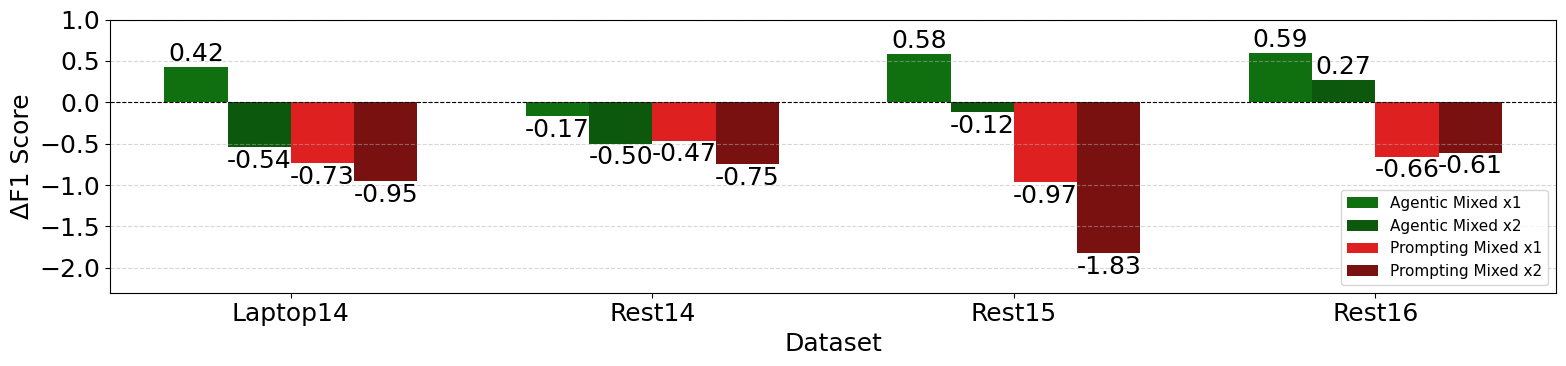

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 11,
    "legend.title_fontsize": 12
})
# Step 1: Tag tasks
ate["Task"] = "ate"
atsc["Task"] = "atsc"
aspe["Task"] = "aspe"

all_df = pd.concat([ate, atsc, aspe], ignore_index=True)

# Filter the needed rows
filtered = all_df[
    all_df["Variation"].isin(["Mixed x1", "Mixed x2"]) &
    all_df["Data_Source"].isin(["Agentic", "Prompting"])
]

# Diff columns to average (relative to original)
diff_cols = ["Laptop14_Diff", "Rest14_Diff", "Rest15_Diff", "Rest16_Diff"]

# Group by source and variation, average across tasks and models
grouped_diff = (
    filtered
    .groupby(["Data_Source", "Variation"])[diff_cols]
    .mean()
    .reset_index()
)

# Reshape for plotting
melted_diff = grouped_diff.melt(
    id_vars=["Data_Source", "Variation"],
    value_vars=diff_cols,
    var_name="Dataset",
    value_name="Delta_F1"
)
dataset_label_map = {
    "Laptop14_Diff": "Laptop14",
    "Rest14_Diff": "Rest14",
    "Rest15_Diff": "Rest15",
    "Rest16_Diff": "Rest16"
}
melted_diff["Dataset"] = melted_diff["Dataset"].map(dataset_label_map)

# Label for plot
melted_diff["Group"] = melted_diff["Data_Source"] + " " + melted_diff["Variation"]



# Plot
plt.figure(figsize=(16, 4))
ax = sns.barplot(
    data=melted_diff,
    x="Dataset",
    y="Delta_F1",
    hue="Group",
    palette=["green", "darkgreen", "red", "darkred"],
    width=0.7
)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", label_type="edge", padding=1, fontsize=18)
# Style
ax.set_ylabel("ΔF1 Score")
ax.set_xlabel("Dataset")
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.yaxis.set_major_locator(MultipleLocator(0.5))  # Grid lines every 0.1
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.set_ylim([-2.3, 1])
ax.legend( loc="lower right")

plt.tight_layout()
plt.show()

In [48]:
import seaborn as sns

# Concatenate all three task dataframes
all_results = pd.concat([ate, atsc, aspe], ignore_index=True)

# Filter to keep only rows with "Mixed x1" or "Original" variations
filtered_results = all_results[all_results["Variation"] == "Mixed x1"]


# Drop 'Model' and group by Data_Source and Task
grouped_avg = (
    filtered_results
    .drop(columns=["Model", "Unnamed: 0", "Variation"])
    .groupby(["Data_Source", "Task"], as_index=False)
    .mean(numeric_only=True)
)
grouped_avg


,Data_Source,Task,Laptop14_F1,Rest14_F1,Rest15_F1,Rest16_F1,Laptop14_Diff,Rest14_Diff,Rest15_Diff,Rest16_Diff
0,Agentic,aspe,81.830,81.345,76.395,80.260,0.220,-0.570,1.080,-0.275
1,Agentic,ate,93.875,94.415,82.550,86.175,0.260,-0.650,0.395,1.800
2,Agentic,atsc,82.050,87.540,88.920,93.330,0.785,0.710,0.270,0.250
3,Prompting,aspe,80.570,80.820,73.665,78.280,-1.040,-1.095,-1.650,-2.255
4,Prompting,ate,93.315,94.315,81.365,84.575,-0.300,-0.750,-0.790,0.200
5,Prompting,atsc,80.400,87.270,88.185,93.170,-0.865,0.440,-0.465,0.090


In [49]:
gen_results = all_results[all_results["Variation"] == "Gen. x1"]

In [50]:
gen_summery = (
    gen_results
    .drop(columns=["Model", "Unnamed: 0", "Variation"])
    .groupby(["Data_Source"], as_index=False)
    .mean(numeric_only=True)
)
gen_summery.drop(columns=["Laptop14_Diff",  "Rest14_Diff", "Rest15_Diff", "Rest16_Diff"], inplace=True)

print(gen_summery)


  Data_Source  Laptop14_F1  Rest14_F1  Rest15_F1  Rest16_F1
0     Agentic    50.971667  64.938333  56.898333  62.601667
1   Prompting    46.108333  57.491667  52.948333  56.525000


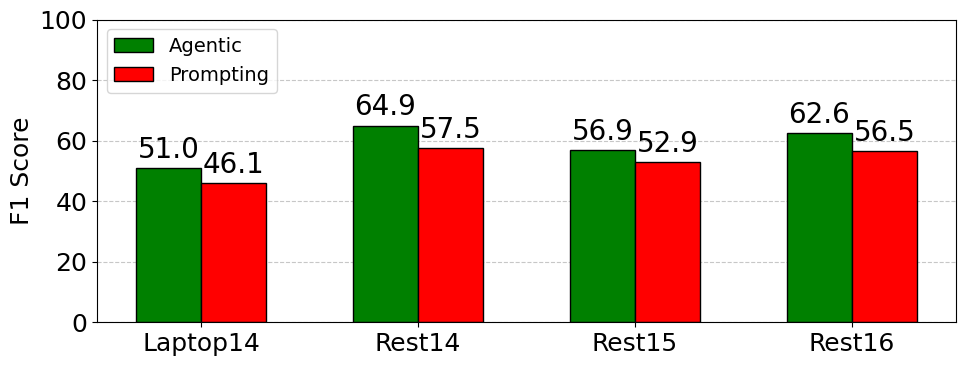

In [51]:
import numpy as np

import matplotlib.pyplot as plt

# Set up the figure
fig, ax = plt.subplots(figsize=(10, 4))

plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 11,
    "legend.title_fontsize": 12
})

# Define width of bars and positions
bar_width = 0.3
datasets = ["Laptop14", "Rest14", "Rest15", "Rest16"]
x = np.arange(len(datasets))

# Plot bars for each data source
agentic_bars = ax.bar(x - bar_width/2, gen_summery.iloc[0, 1:].values, 
                     bar_width, label='Agentic', color='green', edgecolor='black')
prompting_bars = ax.bar(x + bar_width/2, gen_summery.iloc[1, 1:].values, 
                       bar_width, label='Prompting', color='red', edgecolor='black')

# Add values on top of bars
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=20)

add_labels(agentic_bars)
add_labels(prompting_bars)

# Customize the plot
ax.set_ylabel('F1 Score', fontsize=18)
ax.set_xticks(x)
ax.set_xticklabels(datasets)
ax.legend(loc='upper left', fontsize=14)

# Add grid for better readability
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

# Set y-axis to start from 0
ax.set_ylim(0, max(gen_summery.iloc[:, 1:].values.max() * 1.1, 100))

plt.tight_layout()
plt.show()

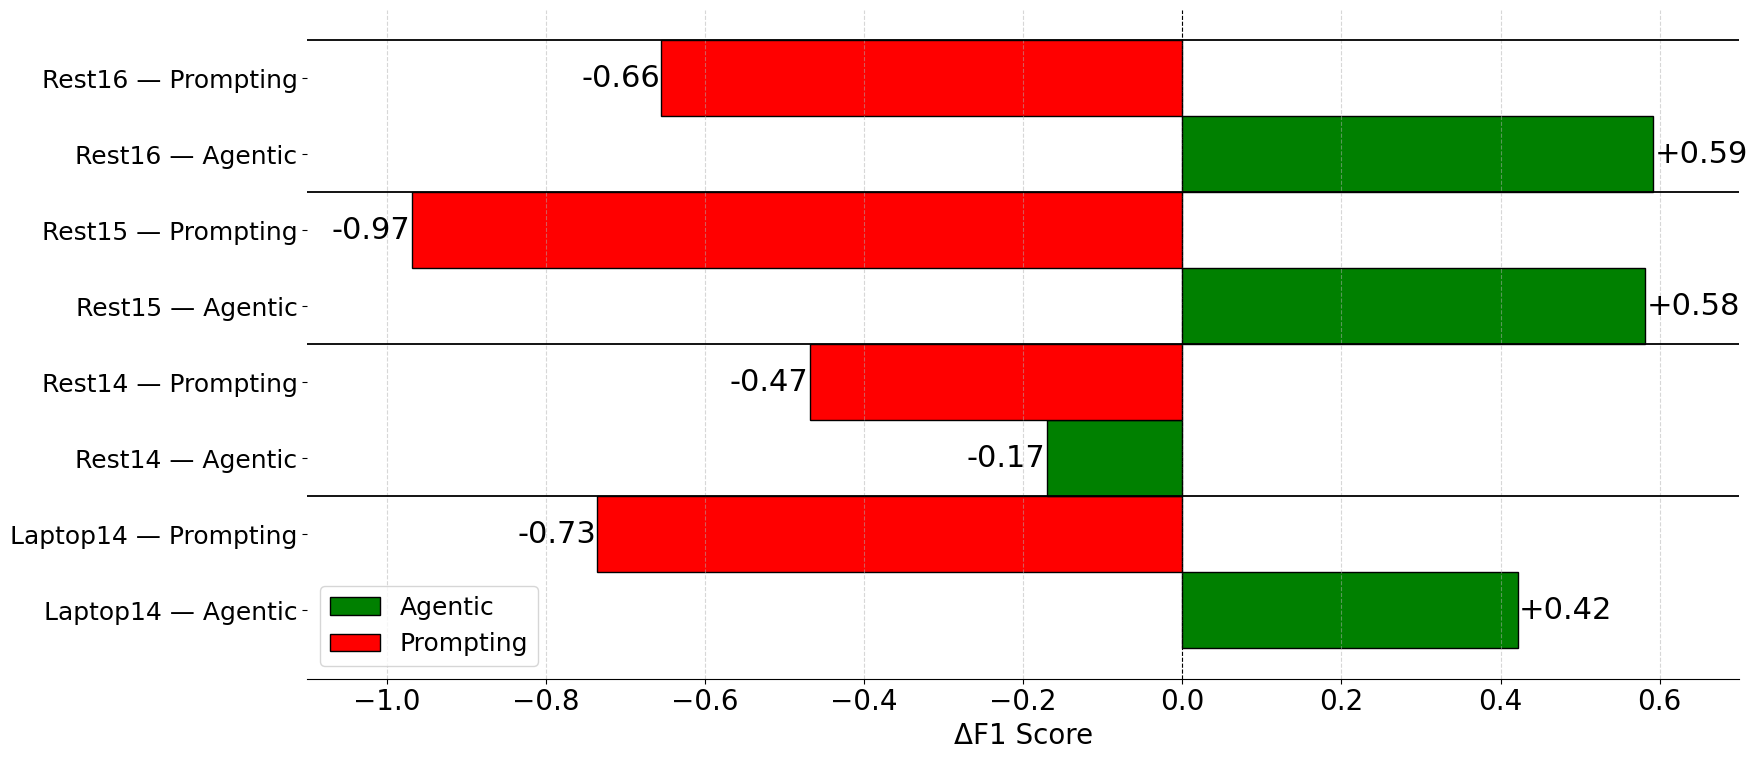

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Compute average ΔF1 per Data_Source per Dataset
delta_cols = ["Laptop14_Diff", "Rest14_Diff", "Rest15_Diff", "Rest16_Diff"]
melted = filtered_results.melt(
    id_vars=["Data_Source"],
    value_vars=delta_cols,
    var_name="Dataset",
    value_name="Delta_F1"
)

# Clean dataset names for labels
melted["Dataset"] = melted["Dataset"].str.replace("_Diff", "").str.replace("F1", "")

# Step 2: Group by Data_Source and Dataset
grouped = (
    melted.groupby(["Dataset", "Data_Source"], as_index=False)
    .mean(numeric_only=True)
)

# Step 3: Prepare for diverging horizontal plot
grouped["Label"] = grouped["Dataset"] + " — " + grouped["Data_Source"]
grouped = grouped.sort_values(by=["Dataset", "Data_Source"])

# Assign colors
grouped["Color"] = grouped["Data_Source"].map({
    "Agentic": "green",
    "Prompting": "red"
})

plt.rcParams.update({
    "font.size": 20,
    "axes.titlesize": 18,
    "axes.labelsize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
    "legend.title_fontsize": 18
})
# Step 4: Plot
plt.figure(figsize=(18, 8))
ax = plt.gca()

bars = ax.barh(
    y=grouped["Label"],
    width=grouped["Delta_F1"],
    color=grouped["Color"],
    edgecolor="black",
    height=1
)

# Value annotations
for bar in bars:
    width = bar.get_width()
    ax.annotate(f'{width:+.2f}',
                xy=(width, bar.get_y() + bar.get_height() / 2),
                xytext=(1 if width >= 0 else -1, 0),
                textcoords='offset points',
                ha='left' if width >= 0 else 'right',
                va='center',
                fontsize=22)

# Separator lines between datasets
for i in range(1, len(grouped), 2):
    ax.axhline(i + 0.5, color='black', linewidth=1.3, alpha=1)

# Styling
ax.axvline(0, color='black', linestyle='--', linewidth=0.8)
ax.set_xlabel("ΔF1 Score")
ax.set_xlim([-1.1, 0.7])
ax.set_ylabel("")
ax.grid(axis="x", linestyle="--", alpha=0.5)
ax.spines[['top', 'right', 'left']].set_visible(False)
from matplotlib.patches import Patch

# Custom legend handles
legend_handles = [
    Patch(facecolor='green', edgecolor='black', label='Agentic'),
    Patch(facecolor='red', edgecolor='black', label='Prompting')
]

# Add legend
ax.legend(handles=legend_handles,  loc="lower left")
plt.tight_layout()
plt.show()

In [53]:
print(grouped)

    Dataset Data_Source  Delta_F1                 Label  Color
0  Laptop14     Agentic  0.421667    Laptop14 — Agentic  green
1  Laptop14   Prompting -0.735000  Laptop14 — Prompting    red
2    Rest14     Agentic -0.170000      Rest14 — Agentic  green
3    Rest14   Prompting -0.468333    Rest14 — Prompting    red
4    Rest15     Agentic  0.581667      Rest15 — Agentic  green
5    Rest15   Prompting -0.968333    Rest15 — Prompting    red
6    Rest16     Agentic  0.591667      Rest16 — Agentic  green
7    Rest16   Prompting -0.655000    Rest16 — Prompting    red


In [54]:
def keep_original_and_agentic_mix1(df):
    return df[
        ((df["Data_Source"] == "Original") & (df["Variation"] == "Original")) |
        ((df["Data_Source"] == "Agentic") & (df["Variation"] == "Mixed x1"))    ].copy()

In [55]:
ate_filtered = keep_original_and_agentic_mix1(ate)
atsc_filtered = keep_original_and_agentic_mix1(atsc)
aspe_filtered = keep_original_and_agentic_mix1(aspe)
aspe_filtered.columns

Index(['Unnamed: 0', 'Model', 'Data_Source', 'Variation', 'Laptop14_F1',
       'Rest14_F1', 'Rest15_F1', 'Rest16_F1', 'Task', 'Laptop14_Diff',
       'Rest14_Diff', 'Rest15_Diff', 'Rest16_Diff'],
      dtype='object')

In [56]:
import numpy as np

# Concatenate the filtered dataframes
all_filtered = pd.concat([ate_filtered, atsc_filtered, aspe_filtered], ignore_index=True)
# Group by model/data settings and average across tasks
averaged = (
    all_filtered.groupby(["Model", "Data_Source", "Variation"], as_index=False)[
        ["Laptop14_F1", "Rest14_F1", "Rest15_F1", "Rest16_F1"]
    ].mean()
)

# Merge with one representative task row to keep structure (e.g., Task, Unnamed: 0, etc.)
# Drop duplicates to get one row per Model/Data_Source/Variation
meta = all_filtered.drop_duplicates(subset=["Model", "Data_Source", "Variation"])[
    ["Unnamed: 0", "Model", "Data_Source", "Variation", "Task"]
]

# Merge metadata with averaged F1s
result_df = pd.merge(meta, averaged, on=["Model", "Data_Source", "Variation"])


print(result_df)

   Unnamed: 0        Model Data_Source Variation Task  Laptop14_F1  Rest14_F1  \
0           0      T5-Base    Original  Original  ate    84.763333  87.570000   
1           5      T5-Base     Agentic  Mixed x1  ate    86.523333  87.240000   
2           9  Tk-Instruct    Original  Original  ate    86.230000  88.303333   
3          14  Tk-Instruct     Agentic  Mixed x1  ate    85.313333  88.293333   

   Rest15_F1  Rest16_F1  
0  81.006667  84.870000  
1  81.966667  86.086667  
2  83.073333  87.123333  
3  83.276667  87.090000  


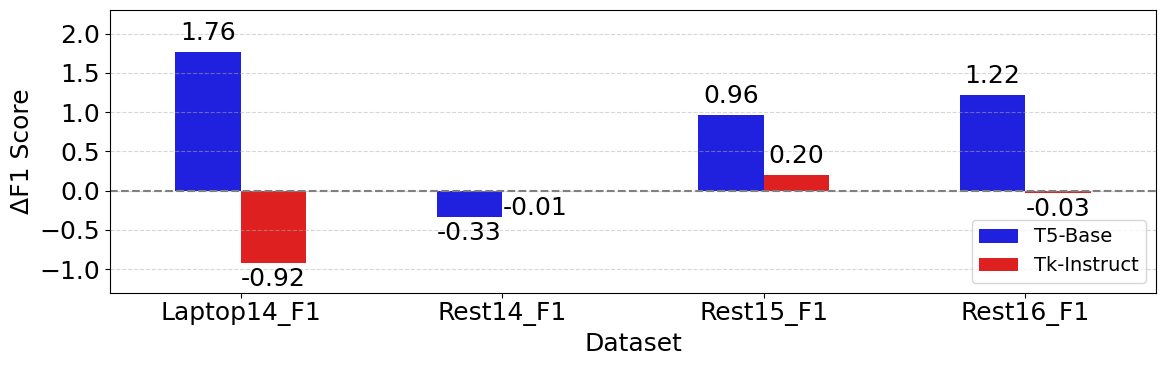

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Filter only the needed rows
original = result_df[result_df["Variation"] == "Original"].copy()
mixed = result_df[result_df["Variation"] == "Mixed x1"].copy()

# Step 2: Merge on Model AND Task to avoid duplicates
merged = pd.merge(mixed, original, on=["Model", "Task"], suffixes=("_mixed", "_orig"))

# Step 3: Compute deltas
datasets = ["Laptop14_F1", "Rest14_F1", "Rest15_F1", "Rest16_F1"]
delta_f1 = pd.DataFrame({"Model": merged["Model"]})

for d in datasets:
    delta_f1[d] = merged[f"{d}_mixed"] - merged[f"{d}_orig"]

# Step 4: Reshape for plotting
delta_f1_long = delta_f1.melt(id_vars="Model", var_name="Dataset", value_name="Delta_F1")


plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 14,
    "legend.title_fontsize": 14
})
# Step 5: Plot
plt.figure(figsize=(12, 4))
palette = {
    "T5-Base": "blue",
    "Tk-Instruct": "red"
}

ax = sns.barplot(data=delta_f1_long, x="Dataset", y="Delta_F1", hue="Model", palette=palette , width = 0.5)

# Grid styling
ax.yaxis.grid(True)
ax.xaxis.grid(False)

# Annotate bars
for p in ax.patches:
    height = p.get_height()
    if height != 0:  # 👈 Avoid labeling zero-height bars
        ax.annotate(f'{height:.2f}',
                    xy=(p.get_x() + p.get_width() / 2, height),
                    xytext=(0, 5 if height > 0 else -3),
                    textcoords='offset points',
                    ha='center', va='bottom' if height > 0 else 'top')

# Final polish
ax.set_ylabel("ΔF1 Score")
ax.set_xlabel("Dataset")
ax.set_ylim([-1.3, 2.3])
ax.legend(loc="lower right")
ax.yaxis.set_major_locator(MultipleLocator(0.5)) 
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.axhline(0, color='gray', linestyle='--')

plt.tight_layout()
plt.show()


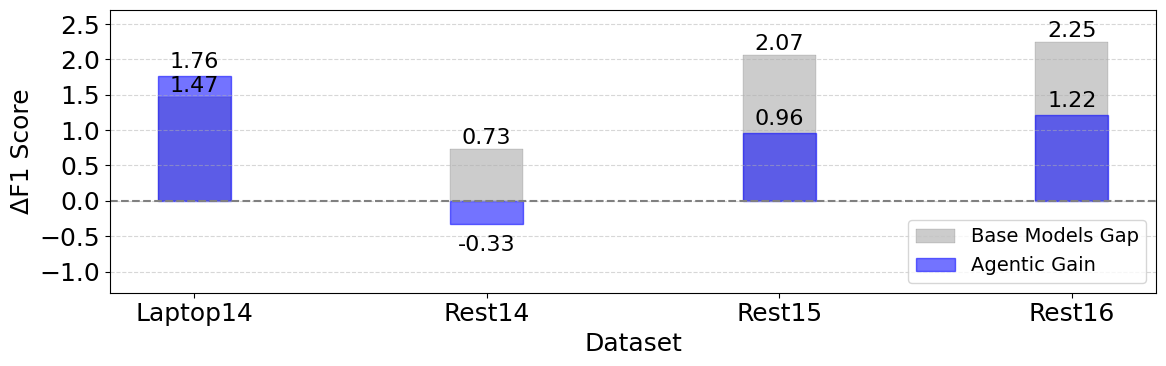

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# --- Step 1: Extract relevant rows ---
t5_orig = result_df[(result_df["Model"] == "T5-Base") & (result_df["Variation"] == "Original")].iloc[0]
t5_agentic = result_df[(result_df["Model"] == "T5-Base") & (result_df["Variation"] == "Mixed x1")].iloc[0]
tk_orig = result_df[(result_df["Model"] == "Tk-Instruct") & (result_df["Variation"] == "Original")].iloc[0]

# --- Step 2: Compute gap and gain ---
datasets = ["Laptop14_F1", "Rest14_F1", "Rest15_F1", "Rest16_F1"]
data = []

for ds in datasets:
    dataset_name = ds.replace("_F1", "")
    gap = tk_orig[ds] - t5_orig[ds]
    gain = t5_agentic[ds] - t5_orig[ds]
    data.append({"Dataset": dataset_name, "Gap": gap, "Gain": gain})

plot_df = pd.DataFrame(data)

# --- Style params (same as Plot 1) ---
plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 14,
    "legend.title_fontsize": 14
})

# --- Step 3: Plot ---
fig, ax = plt.subplots(figsize=(12, 4))
bar_width = 0.25
positions = range(len(plot_df))

# Background gap bars
ax.bar(
    positions,
    plot_df["Gap"],
    color="gray",
    alpha=0.4,
    width=bar_width,
    label="Base Models Gap",
    edgecolor="black",
    linewidth=0.2,
)

# Foreground gain bars
ax.bar(
    positions,
    plot_df["Gain"],
    color="blue",
    alpha=0.55,
    width=bar_width,
    label="Agentic Gain",
    edgecolor="blue",
)

# Add value annotations
for i, row in plot_df.iterrows():
    if row["Gain"] != 0:
        ax.annotate(f"{row['Gain']:.2f}",
                    (i, row['Gain']),
                    xytext=(0, 3 if row['Gain'] > 0 else -8),
                    textcoords='offset points',
                    ha="center", va="bottom" if row['Gain'] > 0 else "top",
                    fontsize=16)
    if row["Gap"] != 0:
        ax.annotate(f"{row['Gap']:.2f}",
                    (i, row['Gap']),
                    xytext=(0, 0.5 if row['Gap'] > 0 else -8),
                    textcoords='offset points',
                    ha="center", va="bottom" if row['Gap'] > 0 else "top",
                    fontsize=16)

# --- Final styling (match Plot 1) ---
ax.set_xticks(positions)
ax.set_xticklabels(plot_df["Dataset"], fontsize=18)
ax.set_ylabel("ΔF1 Score")
ax.axhline(0, color='gray', linestyle='--')

# Grid and limits (exactly as Plot 1)
ax.yaxis.set_major_locator(MultipleLocator(0.5))
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.xaxis.grid(False)
ax.set_xlabel("Dataset")
ax.set_ylim([-1.3, 2.7])

# Legend same position
ax.legend(loc="lower right", frameon=True)

plt.tight_layout()
plt.show()


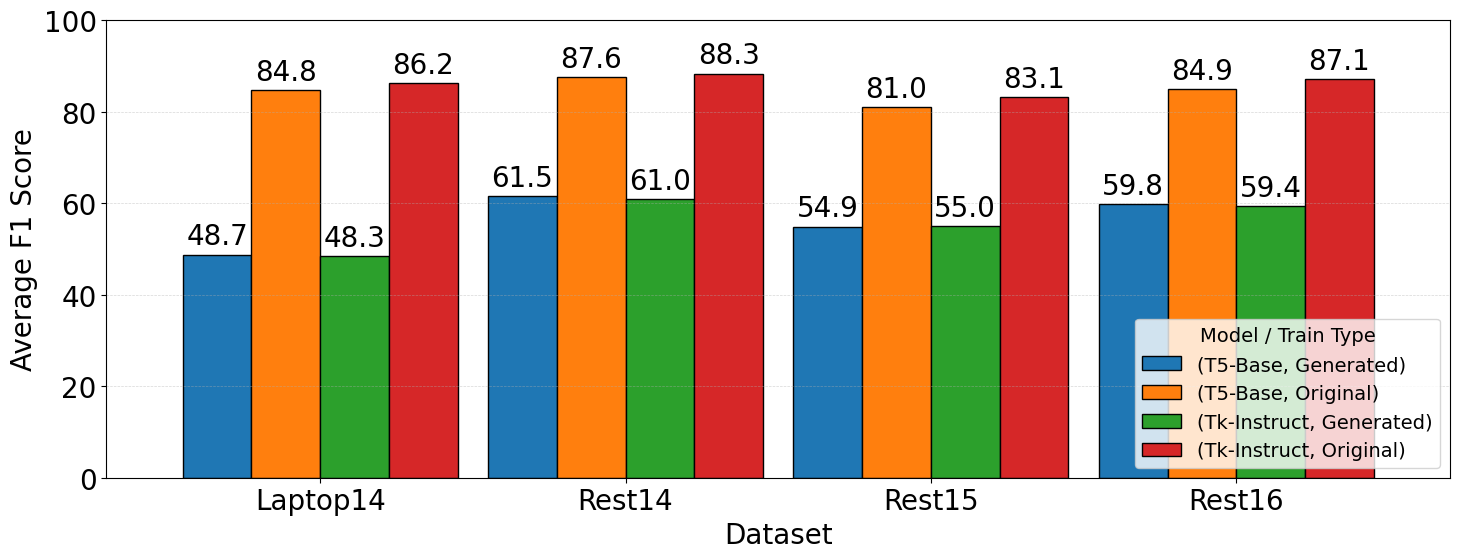

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Read and label tasks
ate = pd.read_csv("/home/s6moakba/Thesis/abc/ATE_all_results.csv")
atsc = pd.read_csv("/home/s6moakba/Thesis/abc/ATSC_all_results.csv")
aspe = pd.read_csv("/home/s6moakba/Thesis/abc/ASPE_all_results.csv")

ate["Task"] = "ATE"
atsc["Task"] = "ATSC"
aspe["Task"] = "ASPE"

plt.rcParams.update({
    "font.size": 20,            # Controls default text size
    "axes.labelsize": 20,       # Axis label font size
    "xtick.labelsize": 20,      # X-axis tick label size
    "ytick.labelsize": 20,      # Y-axis tick label size
    "legend.fontsize": 14,      # Legend font size
    "legend.title_fontsize": 14 # Legend title font size
})
# Combine all
df = pd.concat([ate, atsc, aspe], ignore_index=True)

# Select Original and Generated-only
is_generated = df["Variation"].str.contains("Gen. x1", case=False)
is_original = df["Data_Source"] == "Original"
filtered = df[is_generated | is_original].copy()

# Tag training type
filtered["Train_Type"] = filtered["Data_Source"].apply(lambda x: "Original" if x == "Original" else "Generated")

# Melt datasets into one column
melted = filtered.melt(
    id_vars=["Model", "Task", "Train_Type"],
    value_vars=["Laptop14_F1", "Rest14_F1", "Rest15_F1", "Rest16_F1"],
    var_name="Dataset",
    value_name="F1"
)

# Clean up dataset names
melted["Dataset"] = melted["Dataset"].str.replace("_F1", "").str.replace("Laptop14", "Laptop14").str.replace("Rest", "Rest")

# Group and average
summary = melted.groupby(["Model", "Train_Type", "Dataset"], as_index=False)["F1"].mean()

# Pivot for plotting
pivot = summary.pivot_table(index="Dataset", columns=["Model", "Train_Type"], values="F1")

# Plot
fig, ax = plt.subplots(figsize=(15, 6))
pivot.plot(kind="bar", ax=ax, ylim=(0, 100),width=0.9, edgecolor='black')

# Axis labels and title
ax.set_ylabel("Average F1 Score")
ax.set_xticklabels(pivot.index, rotation=0)

# Horizontal grid only
ax.yaxis.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.5)
ax.xaxis.grid(False)

# Annotate bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", label_type="edge", padding=3)

# Move legend outside plot (right side)
# ax.legend(title="Model / Train Type", bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
ax.legend(title="Model / Train Type", loc='lower right')
plt.tight_layout()
plt.show()


In [ ]:
og_df = pd.read_csv("/home/s6moakba/InstructABSA/Dataset/SemEval14/Train/Laptops_Train.csv")

# Display basic info
print(f"Original dataset shape: {og_df.shape}")

# Drop rows where aspectTerms contains 'noaspectterm'
og_df = og_df[og_df['aspectTerms'] != "[{'term': 'noaspectterm', 'polarity': 'none'}]"]

print(f"Dataset shape after dropping rows with 'noaspectterm': {og_df.shape}")

# Sample 20 rows and display their raw_text
sample_rows = og_df.sample(20, random_state=22)
print("\nSample texts:")
for i, row in enumerate(sample_rows.iterrows()):
    print(f"Text {i+1}: {row[1]['raw_text']}")
    print(f"Aspect Terms: {row[1]['aspectTerms']}\n")

# Check how many sentences have aspects
has_aspects = og_df['aspectTerms'].apply(lambda x: x != "[{'term': 'noaspectterm', 'polarity': 'none'}]")
print(f"\nSentences with aspects: {has_aspects.sum()} out of {len(og_df)} ({has_aspects.mean()*100:.2f}%)")



Original dataset shape: (3045, 4)
Dataset shape after dropping rows with 'noaspectterm': (1488, 4)

Sample texts:
Text 1: Supplied software: The software that comes with this machine is greatly welcomed compared to what Windows comes with.
Aspect Terms: [{'term': 'Supplied software', 'polarity': 'neutral'}, {'term': 'software', 'polarity': 'positive'}, {'term': 'Windows', 'polarity': 'negative'}]

Text 2: All the programs are easy and straight forward on my MacBook Pro, it is clean and organized, which I always strive to be myself.
Aspect Terms: [{'term': 'programs', 'polarity': 'positive'}]

Text 3: I have been very pleased with the performance of this laptop.
Aspect Terms: [{'term': 'performance', 'polarity': 'positive'}]

Text 4: This laptop looked brand new and was shipped very quickly.
Aspect Terms: [{'term': 'shipped', 'polarity': 'positive'}]

Text 5: One drawback I noticed was sound quality via USB.
Aspect Terms: [{'term': 'sound quality via USB', 'polarity': 'negative'}]

Text

In [ ]:
import pandas as pd
p = '/home/s6moakba/InstructABSA/Dataset/AUG/16/Agentic_16_5k.csv'

agent = pd.read_csv(p)

sample_rows = agent.sample(20, random_state=22)

for i, row in enumerate(sample_rows.iterrows()):
    print(f"Text {i+1}: {row[1]['raw_text']}")
    print(f"Aspect Terms: {row[1]['aspectTerms']}\n")

Text 1: The chef prepared the dishes competently, and the wine list offered a decent selection of options
Aspect Terms: [{'term': 'chef', 'polarity': 'neutral'}, {'term': 'wine list', 'polarity': 'positive'}]

Text 2: Pacifico is a refreshing choice on hot days!
Aspect Terms: [{'term': 'Pacifico', 'polarity': 'positive'}]

Text 3: The indian food was bland and lacked flavor
Aspect Terms: [{'term': 'indian food', 'polarity': 'negative'}]

Text 4: The maitre-D was super friendly and made us feel right at home!
Aspect Terms: [{'term': 'maitre-D', 'polarity': 'positive'}]

Text 5: The fried dumplings were crispy and delicious!
Aspect Terms: [{'term': 'fried dumplings', 'polarity': 'positive'}]

Text 6: The fish and chips were crispy and delicious, the vibe was awesome, and the martinis hit the spot; there wasn't much to complain about the sitting space though
Aspect Terms: [{'term': 'fish and chips', 'polarity': 'positive'}, {'term': 'vibe', 'polarity': 'positive'}, {'term': 'martinis', 'p

In [ ]:
p_p = '/home/s6moakba/InstructABSA/Dataset/AUG/16/prompting_16_5k.csv'

prompting = pd.read_csv(p_p)
sample_rows_p = prompting.sample(20, random_state=22)
for i, row in enumerate(sample_rows_p.iterrows()):
    print(f"Text {i+1}: {row[1]['raw_text']}")
    print(f"Aspect Terms: {row[1]['aspectTerms']}\n")

Text 1: The chicken was overcooked and dry, while the mashed potatoes were bland and lacked flavor
Aspect Terms: [{'term': 'chicken and mashed potatos', 'polarity': 'negative'}]

Text 2: The kimchi was just okay, but the Japanese food, Ow Ley Soh, and Hot Dogs were all disappointing
Aspect Terms: [{'term': 'kimchi', 'polarity': 'neutral'}, {'term': 'Japanese food', 'polarity': 'negative'}, {'term': 'Ow Ley Soh', 'polarity': 'negative'}, {'term': 'Hot Dogs', 'polarity': 'negative'}]

Text 3: The wait staff at Pizza 33 was friendly and attentive, but the service was slow despite the delicious salmon
Aspect Terms: [{'term': 'Pizza 33', 'polarity': 'negative'}, {'term': 'wait staff', 'polarity': 'positive'}, {'term': 'salmon', 'polarity': 'positive'}]

Text 4: The Slamwich was a delightful surprise, but the eggplant was disappointingly bland and overcooked
Aspect Terms: [{'term': 'Slamwich', 'polarity': 'positive'}, {'term': 'eggplant', 'polarity': 'negative'}]

Text 5: The bagels were jus